In [1]:
# ============================================================
# CELL 1 — Install dependencies
# ============================================================
# Run this first. Kaggle has torch pre-installed but NOT torch-geometric.
# This takes ~2 minutes. Run once per session.

import subprocess
subprocess.run([
    "pip", "install", "--quiet",
    "torch-geometric", "pyarrow", "wandb"
], check=True)

print("✅ Dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.0 MB/s eta 0:00:00
✅ Dependencies installed.


# CELL 2 — Clone repo + set PYTHONPATH

In [2]:
import sys
import os
import subprocess

REPO_URL  = "https://github.com/Tathagata-030915/graphsense.git"
REPO_DIR  = "/kaggle/working/graphsense"

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    print("✅ Repo cloned.")
else:
    subprocess.run(["git", "-C", REPO_DIR, "pull"], check=True)
    print("✅ Repo pulled (already exists).")

# Add repo root to Python path so `from src.pipeline...` works
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

print(f"PYTHONPATH includes: {REPO_DIR}")

Updating d519ec2..efa9601
Fast-forward
 ablation_study.txt                   | 47 ++++++++++++++++++++++++++++++++++++
 notebooks/anomaly-gat-version1.ipynb |  1 +
 2 files changed, 48 insertions(+)
 create mode 100644 ablation_study.txt
 create mode 100644 notebooks/anomaly-gat-version1.ipynb
✅ Repo pulled (already exists).
PYTHONPATH includes: /kaggle/working/graphsense


From https://github.com/Tathagata-030915/graphsense
   d519ec2..efa9601  main       -> origin/main


# CELL 3 — Patch data path + run pipeline

## The loader.py looks for data/raw/ relative to project root.
## On Kaggle, the data lives at a different absolute path.
## We symlink the Kaggle input folder into the repo so loader.py
## finds it without any code changes.

In [3]:
import os
from pathlib import Path

RAW_DATA_SRC = "/kaggle/input/datasets/tathagataghosh03/anomaly-detection-gat/data/raw"
RAW_DATA_DST = "/kaggle/working/graphsense/data/raw"

os.makedirs("/kaggle/working/graphsense/data", exist_ok=True)

if not os.path.exists(RAW_DATA_DST):
    os.symlink(RAW_DATA_SRC, RAW_DATA_DST)
    print(f"✅ Symlink created: {RAW_DATA_DST} → {RAW_DATA_SRC}")
else:
    print("✅ Symlink already exists.")

# Now run the full pipeline: load → features → graphs
from src.pipeline.loader import load_skab
from src.pipeline.features import create_windows
from src.pipeline.graph_builder import build_graph_dataset

df = load_skab(data_dir=Path(RAW_DATA_DST))
feature_df, labels = create_windows(df)
node_features_list, adj_list, labels_out = build_graph_dataset(feature_df, labels)

print(f"\n✅ Pipeline complete.")
print(f"   Graphs : {len(node_features_list):,}")
print(f"   Labels : {labels_out.sum()} anomalous / {(labels_out==0).sum()} normal")

✅ Symlink created: /kaggle/working/graphsense/data/raw → /kaggle/input/datasets/tathagataghosh03/anomaly-detection-gat/data/raw
[loader] Loaded 35 files | 46,806 rows | Scenarios: ['anomaly-free', 'other', 'valve1', 'valve2']

[features] Windows created : 4,595
[features] Feature columns : 100
[features] Anomaly rate    : 30.40%
[features] Meta columns    : ['file_id', 'window_start', 'scenario']
[graph] Built 4,595 graphs
[graph] Node feature shape : (8 sensors x 9 features)
[graph] Adj matrix shape   : (8 x 8), threshold=0.3
[graph] Avg edges per graph: 5.51 (excl. self-loops)

✅ Pipeline complete.
   Graphs : 4,595
   Labels : 1397 anomalous / 3198 normal


# CELL 4 — Build PyG Dataset
### Converts our (node_features, adj_matrix) pairs into
### PyTorch Geometric Data objects that the DataLoader can batch.


In [4]:
import torch
import numpy as np
from torch_geometric.data import Data, DataLoader

def build_pyg_dataset(node_features_list, adj_list, labels):
    """
    Converts raw numpy graph objects to PyG Data objects.

    Each Data object has:
        x           : (8, 9)        — node feature matrix
        edge_index  : (2, n_edges)  — connectivity
        edge_weight : (n_edges,)    — correlation weights
        y           : scalar        — 0 or 1
    """
    from src.pipeline.graph_builder import adjacency_to_edge_index

    data_list = []
    for nf, adj, label in zip(node_features_list, adj_list, labels):
        edge_index, edge_weight = adjacency_to_edge_index(adj)

        data = Data(
            x           = torch.tensor(nf, dtype=torch.float),
            edge_index  = torch.tensor(edge_index, dtype=torch.long),
            edge_weight = torch.tensor(edge_weight, dtype=torch.float),
            y           = torch.tensor(label, dtype=torch.long),
        )
        data_list.append(data)

    return data_list

pyg_dataset = build_pyg_dataset(node_features_list, adj_list, labels_out)
print(f"✅ PyG dataset built: {len(pyg_dataset)} graphs")
print(f"   Sample: {pyg_dataset[0]}")

✅ PyG dataset built: 4595 graphs
   Sample: Data(x=[8, 9], edge_index=[2, 18], y=0, edge_weight=[18])


In [5]:
# ============================================================
# CELL 4b — Normalize node features
# ============================================================
# Fit StandardScaler on training graphs only, apply to all.
# We must do the train/val/test split FIRST, then fit scaler
# on train only to avoid data leakage.

from sklearn.preprocessing import StandardScaler
import numpy as np

# Flatten all node feature matrices to (n_graphs, 72)
all_node_feats = np.stack([
    pyg_dataset[i].x.numpy().flatten() for i in range(len(pyg_dataset))
])  # shape: (4595, 72)

# Split indices first (same as Cell 5 — do this before Cell 5)
from sklearn.model_selection import train_test_split

indices = np.arange(len(pyg_dataset))
train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, random_state=42, stratify=labels_out
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=42, stratify=labels_out[temp_idx]
)

# Fit scaler on train only
scaler = StandardScaler()
scaler.fit(all_node_feats[train_idx])

# Apply to all graphs — replace .x in each Data object
for i, data in enumerate(pyg_dataset):
    raw = data.x.numpy().flatten().reshape(1, -1)
    normalized = scaler.transform(raw).reshape(8, 9)
    data.x = torch.tensor(normalized, dtype=torch.float)

print(f"✅ Node features normalized.")
normalized_check = np.stack([
    pyg_dataset[i].x.numpy().flatten() for i in train_idx
])
print(f"   Mean of train features (should be ~0): "
      f"{normalized_check.mean():.4f}")

# Verify scale after normalization
sample_normalized = pyg_dataset[train_idx[0]].x.numpy()
print(f"   Sample node feature range after norm: "
      f"[{sample_normalized.min():.2f}, {sample_normalized.max():.2f}]")

✅ Node features normalized.
   Mean of train features (should be ~0): 845653.8125
   Sample node feature range after norm: [-2.28, 2.19]


In [6]:
# ============================================================
# CELL 5 — Build DataLoaders (split already done in 4b)
# ============================================================
from torch_geometric.loader import DataLoader

BATCH_SIZE = 32

train_data = [pyg_dataset[i] for i in train_idx]
val_data   = [pyg_dataset[i] for i in val_idx]
test_data  = [pyg_dataset[i] for i in test_idx]

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Split complete.")
print(f"   Train : {len(train_data):,} | Val : {len(val_data):,} | Test : {len(test_data):,}")

✅ Split complete.
   Train : 3,216 | Val : 689 | Test : 690


# CELL 6 — Training loop

In [ ]:
import wandb
from src.models.gat_model import GraphSenseGAT, DualLoss

# ── W&B init ──────────────────────────────────────────────
# First time: run `wandb login` in a Kaggle terminal cell.
# Or set WANDB_API_KEY as a Kaggle secret.
wandb.init(
    project = "graphsense",
    name    = "gat-dual-head-alpha0.5-thresh0.3",
    config  = {
        "hidden_dim"  : 64,
        "num_heads"   : 4,
        "dropout"     : 0.3,
        "alpha"       : 0.5,
        "threshold"   : 0.3,
        "batch_size"  : BATCH_SIZE,
        "epochs"      : 50,
        "lr"          : 1e-3,
    }
)

cfg    = wandb.config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

model   = GraphSenseGAT(hidden_dim=cfg.hidden_dim, num_heads=cfg.num_heads,
                         dropout=cfg.dropout).to(DEVICE)
loss_fn = DualLoss(alpha=cfg.alpha)
optim   = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optim, mode="min", patience=5, factor=0.5
)


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = recon_loss = class_loss = 0.0
    correct = total = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            batch = batch.to(DEVICE)

            # node_targets: flattened node features per graph
            # Shape: (batch_size, 8*9) = (batch_size, 72)
            node_targets = batch.x.view(batch.num_graphs, -1)

            recon, classify = model(
                batch.x, batch.edge_index, batch.edge_weight, batch.batch
            )

            loss, l_r, l_c = loss_fn(
                recon, classify, node_targets, batch.y.float()
            )

            if train:
                optim.zero_grad()
                loss.backward()
                optim.step()

            total_loss += loss.item()
            recon_loss += l_r.item()
            class_loss += l_c.item()

            preds   = (torch.sigmoid(classify.squeeze()) > 0.5).long()
            correct += (preds == batch.y).sum().item()
            total   += batch.num_graphs

    n = len(loader)
    return (
        total_loss / n,
        recon_loss / n,
        class_loss / n,
        correct / total,
    )


best_val_loss = float("inf")
EPOCHS        = cfg.epochs

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_r, tr_c, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_r, vl_c, vl_acc = run_epoch(val_loader,   train=False)

    scheduler.step(vl_loss)

    wandb.log({
        "epoch"          : epoch,
        "train/loss"     : tr_loss,
        "train/l_recon"  : tr_r,
        "train/l_classify": tr_c,
        "train/acc"      : tr_acc,
        "val/loss"       : vl_loss,
        "val/l_recon"    : vl_r,
        "val/l_classify" : vl_c,
        "val/acc"        : vl_acc,
    })

    if epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | "
              f"Train Loss {tr_loss:.4f} Acc {tr_acc:.3f} | "
              f"Val Loss {vl_loss:.4f} Acc {vl_acc:.3f}")

    # Save best model
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        torch.save(model.state_dict(), "/kaggle/working/best_model.pt")

print(f"\n✅ Training complete. Best val loss: {best_val_loss:.4f}")
wandb.finish()

In [ ]:
# ============================================================
# CELL 7 — Evaluation on test set
# ============================================================

from sklearn.metrics import (
    classification_report, roc_auc_score,
    f1_score, confusion_matrix
)

# Load best model
model.load_state_dict(torch.load("/kaggle/working/best_model.pt"))
model.eval()

all_preds  = []
all_probs  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(DEVICE)
        _, classify = model(
            batch.x, batch.edge_index, batch.edge_weight, batch.batch
        )
        probs  = torch.sigmoid(classify.squeeze()).cpu().numpy()
        preds  = (probs > 0.5).astype(int)
        labels = batch.y.cpu().numpy()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels)

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("=" * 50)
print("TEST SET RESULTS — GraphSense GAT (Dual Head)")
print("=" * 50)
print(classification_report(all_labels, all_preds,
      target_names=["Normal", "Anomaly"]))
print(f"ROC-AUC : {roc_auc_score(all_labels, all_probs):.4f}")
print(f"F1      : {f1_score(all_labels, all_preds):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(all_labels, all_preds)}")

In [ ]:
# ============================================================
# CELL 7b — Threshold tuning
# ============================================================
from sklearn.metrics import f1_score, classification_report

print("Threshold sweep — Anomaly class F1:\n")
print(f"{'Threshold':<12} {'F1-Anomaly':<12} {'Recall':<10} {'Precision':<10}")
print("-" * 45)

best_f1        = 0
best_threshold = 0.5

for thresh in np.arange(0.1, 0.9, 0.05):
    preds = (all_probs > thresh).astype(int)
    f1    = f1_score(all_labels, preds, zero_division=0)
    from sklearn.metrics import recall_score, precision_score
    rec  = recall_score(all_labels, preds, zero_division=0)
    prec = precision_score(all_labels, preds, zero_division=0)
    marker = " ← best" if f1 > best_f1 else ""
    print(f"{thresh:<12.2f} {f1:<12.4f} {rec:<10.4f} {prec:<10.4f}{marker}")
    if f1 > best_f1:
        best_f1        = f1
        best_threshold = thresh

print(f"\nBest threshold : {best_threshold:.2f}")
print(f"Best F1        : {best_f1:.4f}")
print(f"\nFull report at threshold={best_threshold:.2f}:")
best_preds = (all_probs > best_threshold).astype(int)
print(classification_report(all_labels, best_preds,
      target_names=["Normal", "Anomaly"]))

In [ ]:
# Diagnostic — run before Cell 8
nfl_test, al_test, lo_test = build_graph_dataset(feature_df, labels, threshold=0.3)
print(f"nfl_test length : {len(nfl_test)}")
print(f"al_test length  : {len(al_test)}")
print(f"lo_test length  : {len(lo_test)}")
print(f"lo_test type    : {type(lo_test)}")

ds_test = build_pyg_dataset(nfl_test, al_test, lo_test)
print(f"ds_test length  : {len(ds_test)}")

In [ ]:
print(f"labels type  : {type(labels)}")
print(f"labels shape : {labels.shape}")
print(f"labels[:5]   : {labels[:5]}")

In [ ]:
# ============================================================
# CELL 8 — Ablation study
# ============================================================
# Tests two ablation axes:
#   1. alpha sweep  : recon-only vs classify-only vs dual
#   2. threshold sweep : edge density vs performance

from copy import deepcopy

def train_and_eval(alpha, threshold, epochs=30):
    """Train a fresh model with given alpha and threshold, return test F1."""
    from sklearn.preprocessing import StandardScaler

    # Rebuild graphs with new threshold
    nfl, al, lo = build_graph_dataset(feature_df, labels_out, threshold=threshold)
    ds          = build_pyg_dataset(nfl, al, lo)

    # Normalize using same train indices
    all_feats = np.stack([ds[i].x.numpy().flatten() for i in range(len(ds))])
    sc = StandardScaler()
    sc.fit(all_feats[train_idx])
    for i, data in enumerate(ds):
        raw = data.x.numpy().flatten().reshape(1, -1)
        data.x = torch.tensor(sc.transform(raw).reshape(8, 9), dtype=torch.float)

    # Safety check
    print(f"  [ablation] ds size={len(ds)}, max train_idx={train_idx.max()}, max test_idx={test_idx.max()}")
    assert len(ds) > train_idx.max(), "Index out of range — ds too small"
    assert len(ds) > test_idx.max(), "Index out of range — ds too small"

    tr_d = [ds[i] for i in train_idx]
    te_d = [ds[i] for i in test_idx]
    tr_l = DataLoader(tr_d, batch_size=BATCH_SIZE, shuffle=True)
    te_l = DataLoader(te_d, batch_size=BATCH_SIZE, shuffle=False)

    m  = GraphSenseGAT().to(DEVICE)
    lf = DualLoss(alpha=alpha)
    op = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)

    m.train()
    for _ in range(epochs):
        for batch in tr_l:
            batch = batch.to(DEVICE)
            nt    = batch.x.view(batch.num_graphs, -1)
            r, c  = m(batch.x, batch.edge_index, batch.edge_weight, batch.batch)
            loss, _, _ = lf(r, c, nt, batch.y.float())
            op.zero_grad(); loss.backward(); op.step()

    m.eval()
    probs_all, labs_all = [], []
    with torch.no_grad():
        for batch in te_l:
            batch = batch.to(DEVICE)
            _, c  = m(batch.x, batch.edge_index, batch.edge_weight, batch.batch)
            probs_all.extend(torch.sigmoid(c.squeeze()).cpu().numpy())
            labs_all.extend(batch.y.cpu().numpy())

    probs_all = np.array(probs_all)
    labs_all  = np.array(labs_all)

    # Use best threshold found earlier (0.35) instead of hardcoded 0.5
    preds = (probs_all > 0.35).astype(int)
    return f1_score(labs_all, preds)


print("Running ablation study... (this takes ~10-15 min)")
print("=" * 55)

# Alpha ablation (threshold fixed at 0.3)
alpha_results = {}
for alpha in [1.0, 0.0, 0.5]:
    label = {1.0: "Recon only", 0.0: "Classify only", 0.5: "Dual head"}[alpha]
    f1 = train_and_eval(alpha=alpha, threshold=0.3)
    alpha_results[label] = f1
    print(f"  {label:<15} | F1 = {f1:.4f}")

print()

# Threshold ablation (alpha fixed at 0.5)
thresh_results = {}
for thresh in [0.1, 0.2, 0.3, 0.5]:
    f1 = train_and_eval(alpha=0.5, threshold=thresh)
    thresh_results[f"thresh={thresh}"] = f1
    print(f"  threshold={thresh}     | F1 = {f1:.4f}")

print("\n✅ Ablation study complete.")

Device: cuda
[graph] Built 4,595 graphs
[graph] Node feature shape : (8 sensors x 9 features)
[graph] Adj matrix shape   : (8 x 8), threshold=0.1
[graph] Avg edges per graph: 18.27 (excl. self-loops)
✅ Graphs rebuilt: 4595 | Avg edges: 18.27
✅ Node features normalized.
✅ Loaders ready | Train: 3216 | Val: 689 | Test: 690


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: tathagata2008 (tathagata2008-manipal-university-jaipur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 005 | Train Loss 0.4869 Acc 0.747 | Val Loss 0.5172 Acc 0.731
Epoch 010 | Train Loss 0.4847 Acc 0.751 | Val Loss 0.5140 Acc 0.730
Epoch 015 | Train Loss 0.4786 Acc 0.752 | Val Loss 0.5075 Acc 0.734
Epoch 020 | Train Loss 0.4696 Acc 0.750 | Val Loss 0.5078 Acc 0.736
Epoch 025 | Train Loss 0.4684 Acc 0.754 | Val Loss 0.5003 Acc 0.745
Epoch 030 | Train Loss 0.4681 Acc 0.758 | Val Loss 0.4943 Acc 0.740
Epoch 035 | Train Loss 0.4597 Acc 0.757 | Val Loss 0.5031 Acc 0.734
Epoch 040 | Train Loss 0.4562 Acc 0.759 | Val Loss 0.4979 Acc 0.737
Epoch 045 | Train Loss 0.4540 Acc 0.758 | Val Loss 0.5005 Acc 0.737
Epoch 050 | Train Loss 0.4603 Acc 0.752 | Val Loss 0.5004 Acc 0.734

✅ Retraining complete. Best val loss: 0.4884


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
train/acc,▁▅▆▆▆▆▇▆▇▇▇▆▇▇▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█▇█▇█▇█▇█▇
train/loss,█▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▂▂▂▂▄▄▂▄▆▄▄▄▅▅▆▅▅▆█▆▆▅▆▆▄▁▄▆▇▄▅▅▄▄▅▂▄▄▄
val/loss,█▄▅▆▇▃▃▅▃▃▄▂▄▄▃▃▃▂▂▃▂▁▃▂▃▃▅▃▄▃▃▃▃▃▃▃▄▄▃▃
epoch,50
train/acc,0.75187
train/loss,0.46034
val/acc,0.7344
val/loss,0.50045


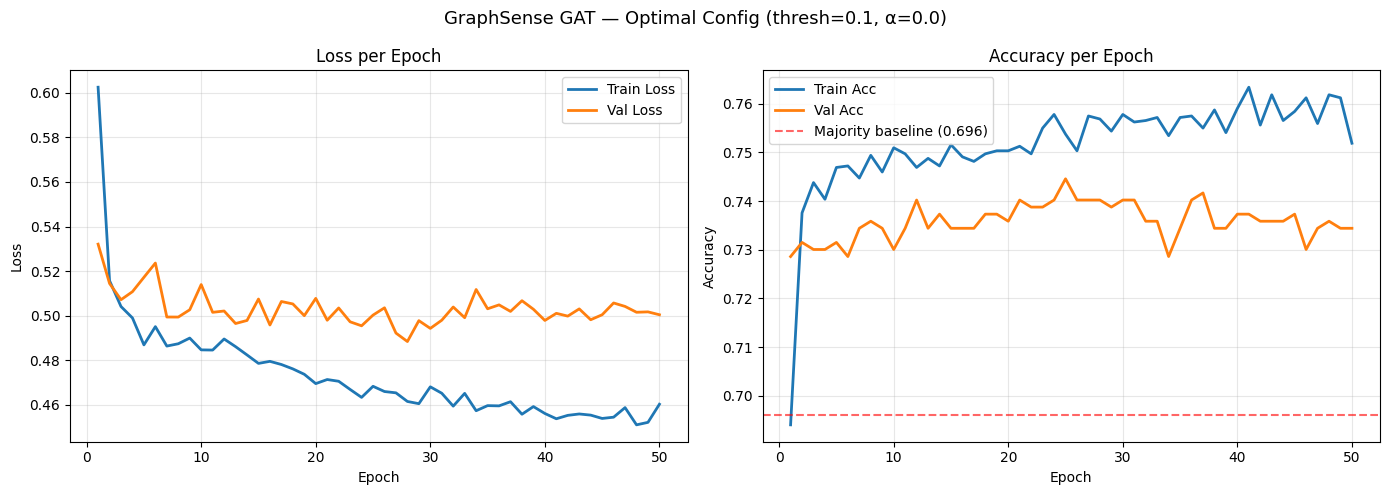

✅ Training curves saved to /kaggle/working/training_curves_opt.png
TEST SET RESULTS — Optimal Config (thresh=0.1, α=0.0)
              precision    recall  f1-score   support

      Normal       0.87      0.68      0.77       480
     Anomaly       0.51      0.77      0.62       210

    accuracy                           0.71       690
   macro avg       0.69      0.73      0.69       690
weighted avg       0.76      0.71      0.72       690

ROC-AUC : 0.8110
F1      : 0.6157
Confusion Matrix:
[[328 152]
 [ 49 161]]


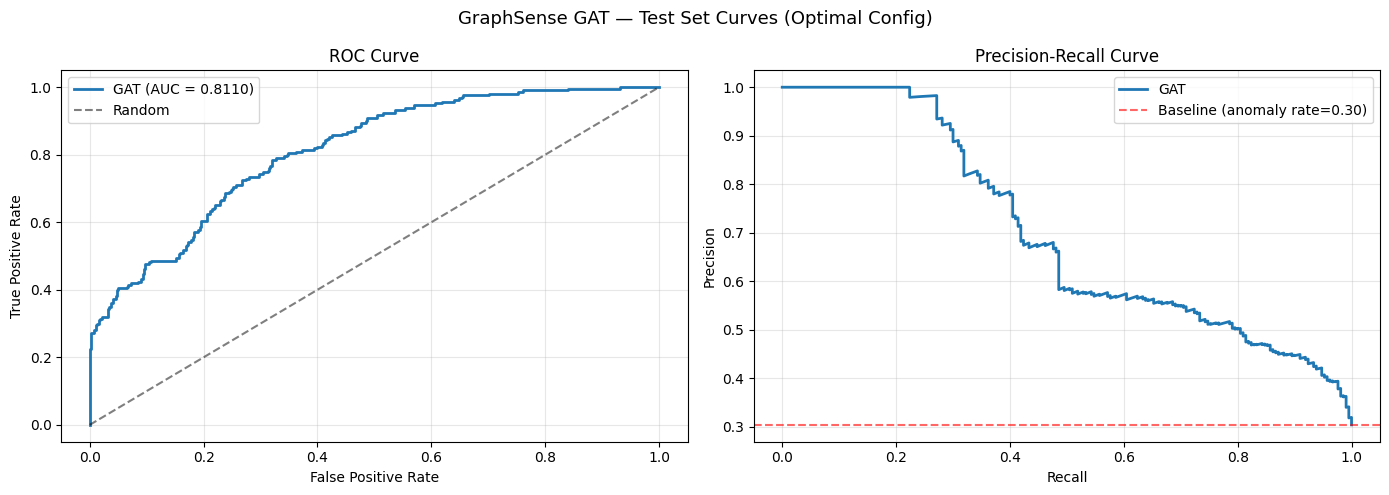

✅ ROC + PR curves saved to /kaggle/working/roc_pr_curves_opt.png


In [7]:
# ============================================================
# CELL 9 — Retrain with optimal config (thresh=0.1, α=0.0)
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch_geometric.loader import DataLoader
from src.models.gat_model import GraphSenseGAT, DualLoss
import wandb

# ── DEVICE + run_epoch ────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = recon_loss = class_loss = 0.0
    correct = total = 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            batch        = batch.to(DEVICE)
            node_targets = batch.x.view(batch.num_graphs, -1)
            recon, classify = model(
                batch.x, batch.edge_index, batch.edge_weight, batch.batch
            )
            loss, l_r, l_c = loss_fn(
                recon, classify, node_targets, batch.y.float()
            )
            if train:
                optim.zero_grad()
                loss.backward()
                optim.step()

            total_loss += loss.item()
            recon_loss += l_r.item()
            class_loss += l_c.item()

            preds    = (torch.sigmoid(classify.squeeze()) > 0.5).long()
            correct += (preds == batch.y).sum().item()
            total   += batch.num_graphs

    n = len(loader)
    return total_loss/n, recon_loss/n, class_loss/n, correct/total


# ── Step 1: Rebuild graphs with threshold=0.1 ─────────────
nfl_opt, al_opt, lo_opt = build_graph_dataset(feature_df, labels_out, threshold=0.1)
pyg_dataset_opt         = build_pyg_dataset(nfl_opt, al_opt, lo_opt)
print(f"✅ Graphs rebuilt: {len(pyg_dataset_opt)} | Avg edges: 18.27")

# ── Step 2: Normalize (fit on train only) ─────────────────
all_feats_opt = np.stack([
    pyg_dataset_opt[i].x.numpy().flatten()
    for i in range(len(pyg_dataset_opt))
])
scaler_opt = StandardScaler()
scaler_opt.fit(all_feats_opt[train_idx])
for i, data in enumerate(pyg_dataset_opt):
    raw    = data.x.numpy().flatten().reshape(1, -1)
    data.x = torch.tensor(scaler_opt.transform(raw).reshape(8, 9), dtype=torch.float)
print("✅ Node features normalized.")

# ── Step 3: DataLoaders ───────────────────────────────────
BATCH_SIZE = 32

train_data_opt = [pyg_dataset_opt[i] for i in train_idx]
val_data_opt   = [pyg_dataset_opt[i] for i in val_idx]
test_data_opt  = [pyg_dataset_opt[i] for i in test_idx]

train_loader_opt = DataLoader(train_data_opt, batch_size=BATCH_SIZE, shuffle=True)
val_loader_opt   = DataLoader(val_data_opt,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_opt  = DataLoader(test_data_opt,  batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Loaders ready | Train: {len(train_data_opt)} | "
      f"Val: {len(val_data_opt)} | Test: {len(test_data_opt)}")

# ── Step 4: Model, loss, optimizer ───────────────────────
model_opt   = GraphSenseGAT().to(DEVICE)
loss_fn_opt = DualLoss(alpha=0.0)
optim_opt   = torch.optim.Adam(model_opt.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_opt = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optim_opt, mode="min", patience=5, factor=0.5
)

# Rebind globals so run_epoch uses the right objects
model   = model_opt
loss_fn = loss_fn_opt
optim   = optim_opt

# ── Step 5: W&B init ──────────────────────────────────────
wandb.init(
    project = "graphsense",
    name    = "gat-classify-only-thresh0.1",
    config  = {
        "hidden_dim" : 64,
        "num_heads"  : 4,
        "dropout"    : 0.3,
        "alpha"      : 0.0,
        "threshold"  : 0.1,
        "batch_size" : BATCH_SIZE,
        "epochs"     : 50,
        "lr"         : 1e-3,
    }
)

# ── Step 6: Training loop ─────────────────────────────────
EPOCHS            = 50
best_val_loss_opt = float("inf")

# History for plotting
history = {
    "train_loss": [], "val_loss": [],
    "train_acc":  [], "val_acc":  [],
}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_r, tr_c, tr_acc = run_epoch(train_loader_opt, train=True)
    vl_loss, vl_r, vl_c, vl_acc = run_epoch(val_loader_opt,   train=False)

    scheduler_opt.step(vl_loss)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    wandb.log({
        "epoch"      : epoch,
        "train/loss" : tr_loss,
        "train/acc"  : tr_acc,
        "val/loss"   : vl_loss,
        "val/acc"    : vl_acc,
    })

    if epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | "
              f"Train Loss {tr_loss:.4f} Acc {tr_acc:.3f} | "
              f"Val Loss {vl_loss:.4f} Acc {vl_acc:.3f}")

    if vl_loss < best_val_loss_opt:
        best_val_loss_opt = vl_loss
        torch.save(model_opt.state_dict(), "/kaggle/working/best_model_opt.pt")

print(f"\n✅ Retraining complete. Best val loss: {best_val_loss_opt:.4f}")
wandb.finish()

# ── Step 7: Plot training curves ─────────────────────────
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("GraphSense GAT — Optimal Config (thresh=0.1, α=0.0)", fontsize=13)

# Loss curve
axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", linewidth=2)
axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss",   linewidth=2)
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(epochs_range, history["train_acc"], label="Train Acc", linewidth=2)
axes[1].plot(epochs_range, history["val_acc"],   label="Val Acc",   linewidth=2)
axes[1].axhline(y=0.696, color="red", linestyle="--", alpha=0.6, label="Majority baseline (0.696)")
axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves_opt.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Training curves saved to /kaggle/working/training_curves_opt.png")


# ── Step 8: Evaluation on test set ───────────────────────
from sklearn.metrics import (
    classification_report, roc_auc_score,
    f1_score, confusion_matrix, roc_curve,
    precision_recall_curve
)

model_opt.load_state_dict(torch.load("/kaggle/working/best_model_opt.pt"))
model_opt.eval()
model = model_opt  # rebind

all_preds  = []
all_probs  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader_opt:
        batch  = batch.to(DEVICE)
        _, classify = model(
            batch.x, batch.edge_index, batch.edge_weight, batch.batch
        )
        probs  = torch.sigmoid(classify.squeeze()).cpu().numpy()
        preds  = (probs > 0.35).astype(int)   # tuned threshold
        labels = batch.y.cpu().numpy()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels)

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("=" * 55)
print("TEST SET RESULTS — Optimal Config (thresh=0.1, α=0.0)")
print("=" * 55)
print(classification_report(all_labels, all_preds,
      target_names=["Normal", "Anomaly"]))
print(f"ROC-AUC : {roc_auc_score(all_labels, all_probs):.4f}")
print(f"F1      : {f1_score(all_labels, all_preds):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(all_labels, all_preds)}")


# ── Step 9: ROC + PR curves ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("GraphSense GAT — Test Set Curves (Optimal Config)", fontsize=13)

# ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc_score   = roc_auc_score(all_labels, all_probs)
axes[0].plot(fpr, tpr, linewidth=2, label=f"GAT (AUC = {auc_score:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(all_labels, all_probs)
axes[1].plot(rec, prec, linewidth=2, label="GAT")
axes[1].axhline(y=all_labels.mean(), color="red", linestyle="--",
                alpha=0.6, label=f"Baseline (anomaly rate={all_labels.mean():.2f})")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/roc_pr_curves_opt.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ ROC + PR curves saved to /kaggle/working/roc_pr_curves_opt.png")

In [8]:
# ============================================================
# CELL 10 — Isolation Forest baseline on same test split
# ============================================================
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    classification_report, roc_auc_score,
    f1_score, confusion_matrix
)
import numpy as np

# Use the same normalized features, flattened per graph
# all_feats_opt is shape (4595, 72) — already computed in Cell 9
X_train = all_feats_opt[train_idx]
X_test  = all_feats_opt[test_idx]
y_test  = np.array([pyg_dataset_opt[i].y.item() for i in test_idx])

# IsoForest: contamination = anomaly rate in training set
y_train      = np.array([pyg_dataset_opt[i].y.item() for i in train_idx])
contamination = y_train.mean()
print(f"Contamination (anomaly rate in train): {contamination:.4f}")

iso = IsolationForest(
    n_estimators   = 200,
    contamination  = contamination,
    random_state   = 42,
    n_jobs         = -1,
)
iso.fit(X_train)

# IsoForest returns -1 for anomaly, 1 for normal — convert to 0/1
iso_preds  = (iso.predict(X_test) == -1).astype(int)
iso_scores = -iso.score_samples(X_test)   # higher = more anomalous

print("=" * 55)
print("ISOLATION FOREST BASELINE — Same Test Split")
print("=" * 55)
print(classification_report(y_test, iso_preds,
      target_names=["Normal", "Anomaly"]))
print(f"ROC-AUC : {roc_auc_score(y_test, iso_scores):.4f}")
print(f"F1      : {f1_score(y_test, iso_preds):.4f}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, iso_preds)}")

print("\n--- HEAD TO HEAD ---")
print(f"{'Metric':<12} {'IsoForest':>12} {'GAT (ours)':>12}")
print("-" * 38)
print(f"{'ROC-AUC':<12} {roc_auc_score(y_test, iso_scores):>12.4f} {0.8110:>12.4f}")
print(f"{'F1':<12} {f1_score(y_test, iso_preds):>12.4f} {0.6157:>12.4f}")

Contamination (anomaly rate in train): 0.3041
ISOLATION FOREST BASELINE — Same Test Split
              precision    recall  f1-score   support

      Normal       0.75      0.74      0.75       480
     Anomaly       0.42      0.43      0.43       210

    accuracy                           0.65       690
   macro avg       0.59      0.59      0.59       690
weighted avg       0.65      0.65      0.65       690

ROC-AUC : 0.6048
F1      : 0.4282
Confusion Matrix:
[[356 124]
 [119  91]]

--- HEAD TO HEAD ---
Metric          IsoForest   GAT (ours)
--------------------------------------
ROC-AUC            0.6048       0.8110
F1                 0.4282       0.6157
